# Sentiment Analysis on IMDB Movie Reviews

**Student:** Fatima Ezzahrae Ezzouzi  
**Course:** Natural Language Processing  
**Dataset:** [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/data)

---

## Objective
Build and compare several machine learning and deep learning models to classify IMDB movie reviews as **positive** or **negative** sentiment.

## Pipeline
1. Data Loading & Initial Exploration  
2. Exploratory Data Analysis (EDA)  
3. Text Preprocessing (HTML removal, tokenization, stop-word filtering, stemming)  
4. Feature Engineering (TF-IDF)  
5. Classical ML Models: Naive Bayes · Logistic Regression · SGD (Linear SVM)  
6. Deep Learning: Bidirectional GRU  
7. Results Comparison & Conclusion  

## 1. Imports & Setup

In [1]:
# ── Install ALL required packages ────────────────────────────────
!pip install wordcloud torch tensorflow nltk seaborn scikit-learn numpy pandas matplotlib --quiet

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Keras (for tokenization/padding)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

sns.set_style('whitegrid')
%matplotlib inline

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\Fatima
[nltk_data]     ezzahrae\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Fatima
[nltk_data]     ezzahrae\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Fatima
[nltk_data]     ezzahrae\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
import os

# ─── Auto-detect environment (Kaggle or local) ───────────────────
KAGGLE_PATH = '/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'
LOCAL_PATH  = os.path.join(os.getcwd(), 'IMDB Dataset.csv')

if os.path.exists(KAGGLE_PATH):
    DATASET_PATH = KAGGLE_PATH
    print("✔ Running on Kaggle")
elif os.path.exists(LOCAL_PATH):
    DATASET_PATH = LOCAL_PATH
    print(f"✔ Running locally → {LOCAL_PATH}")
else:
    raise FileNotFoundError(
        f"\n❌ Dataset not found in:\n  {KAGGLE_PATH}\n  {LOCAL_PATH}\n"
        "Download 'IMDB Dataset.csv' and place it in the same folder as this notebook."
    )

RANDOM_STATE = 42
TEST_SIZE    = 0.2

✔ Running locally → c:\Users\Fatima ezzahrae\Documents\AI_STUDY\NLP\IMDB Dataset.csv


---
## 2. Data Loading & Initial Exploration

In [5]:
df = pd.read_csv(DATASET_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.info()
print("\nClass distribution:")
print(df['sentiment'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [7]:
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"\nShape after deduplication: {df.shape}")

Missing values : 0
Duplicate rows : 418

Shape after deduplication: (49582, 2)


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Class Distribution

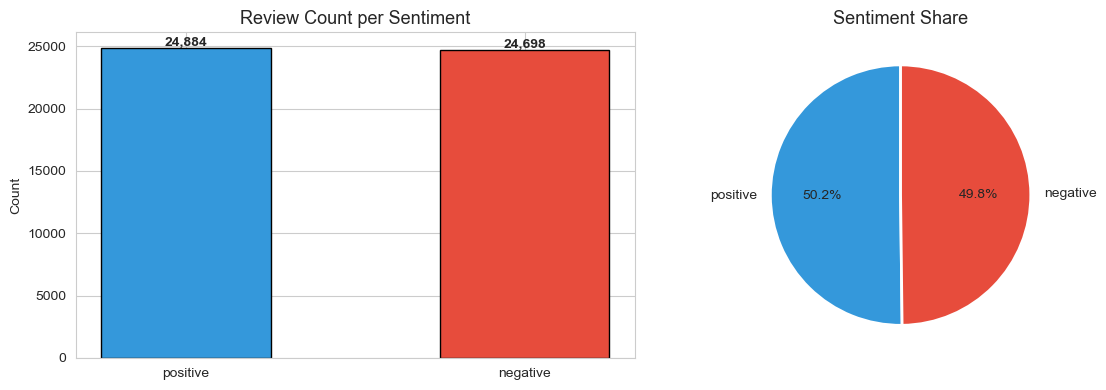

In [8]:
counts = df['sentiment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(counts.index, counts.values,
            color=['#3498db', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Review Count per Sentiment', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 150, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', colors=['#3498db', '#e74c3c'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Sentiment Share', fontsize=13)

plt.tight_layout()
plt.show()

### 3.2 Review Length Distribution

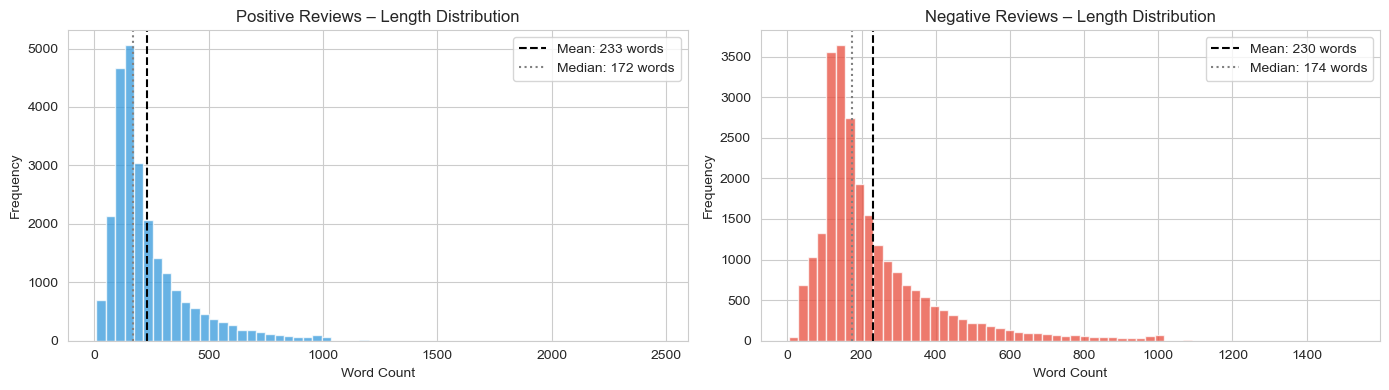

Positive   — mean: 233  median: 172  max: 2470
Negative   — mean: 230  median: 174  max: 1522


In [9]:
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (sentiment, color) in zip(axes, [('positive', '#3498db'), ('negative', '#e74c3c')]):
    data = df[df['sentiment'] == sentiment]['word_count']
    ax.hist(data, bins=60, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {data.mean():.0f} words')
    ax.axvline(data.median(), color='gray', linestyle=':', linewidth=1.5,
               label=f'Median: {data.median():.0f} words')
    ax.set_title(f'{sentiment.capitalize()} Reviews – Length Distribution', fontsize=12)
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

for s in ['positive', 'negative']:
    d = df[df['sentiment'] == s]['word_count']
    print(f"{s.capitalize():10s} — mean: {d.mean():.0f}  median: {d.median():.0f}  max: {d.max()}")

### 3.3 Top 20 Most Frequent Words (raw text)

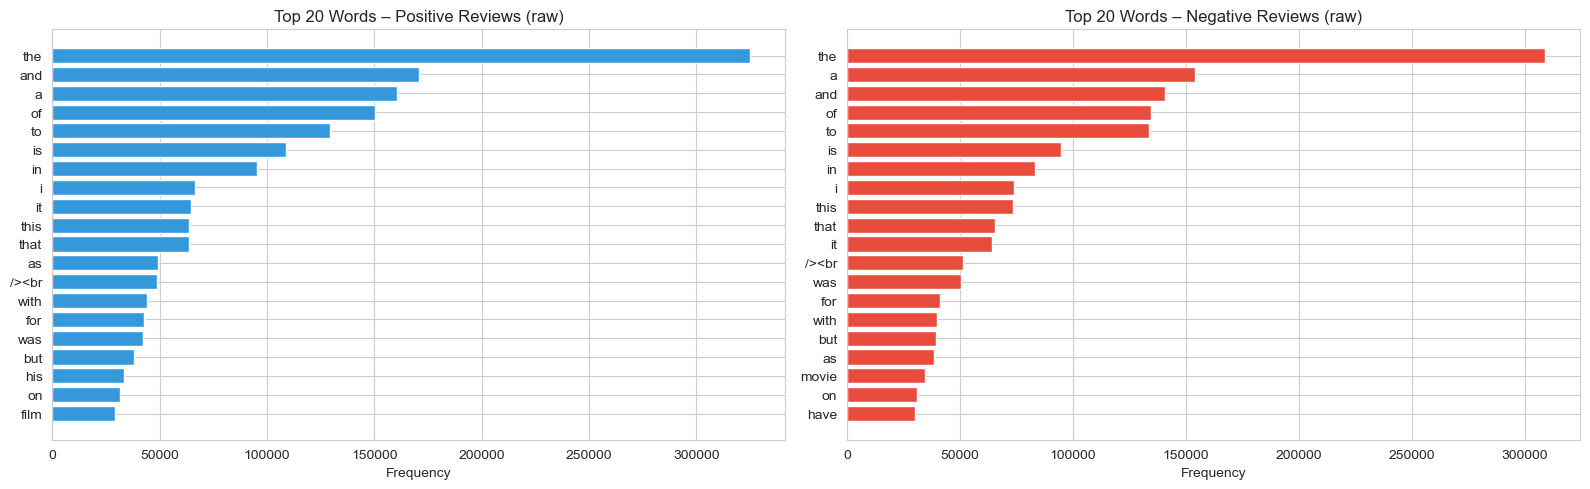

In [10]:
from collections import Counter

def top_words(series, n=20):
    all_words = ' '.join(series).lower().split()
    return pd.Series(Counter(all_words)).nlargest(n)

pos_top = top_words(df[df['sentiment'] == 'positive']['review'])
neg_top = top_words(df[df['sentiment'] == 'negative']['review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, top, color, label in zip(axes,
                                  [pos_top, neg_top],
                                  ['#3498db', '#e74c3c'],
                                  ['Positive', 'Negative']):
    ax.barh(top.index[::-1], top.values[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top 20 Words – {label} Reviews (raw)', fontsize=12)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

---
## 4. Text Preprocessing

Steps applied to each review:
1. **HTML tag removal** – strip `<br />` and other markup
2. **Lowercasing & special-character removal** – keep only alphabetic characters
3. **Tokenization** – split into individual words
4. **Stop-word removal** – discard common English function words
5. **Stemming (Porter)** – reduce words to their root form (e.g. *running* → *run*)

In [11]:
stemmer    = PorterStemmer()
stop_words = set(stopwords.words('english'))

def remove_html_tags(text: str) -> str:
    return re.sub(r'<[^>]+>', ' ', text)

def preprocess(text: str) -> str:
    text   = remove_html_tags(text)
    text   = re.sub(r'[^a-zA-Z\s]', ' ', text.lower())
    tokens = word_tokenize(text)
    tokens = [
        stemmer.stem(w)
        for w in tokens
        if w not in stop_words and len(w) > 2
    ]
    return ' '.join(tokens)

In [12]:
%%time
df['cleaned_review'] = df['review'].apply(preprocess)
print("Preprocessing done.")
df[['review', 'cleaned_review']].head(3)

Preprocessing done.
CPU times: total: 1min 36s
Wall time: 1min 37s


,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one review mention watch episod hook right exa...
1,A wonderful little production. <br /><br />The...,wonder littl product film techniqu unassum old...
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...


In [13]:
# Encode target labels: negative=0, positive=1
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping: {'negative': np.int64(0), 'positive': np.int64(1)}


### 4.1 Word Clouds (after preprocessing)

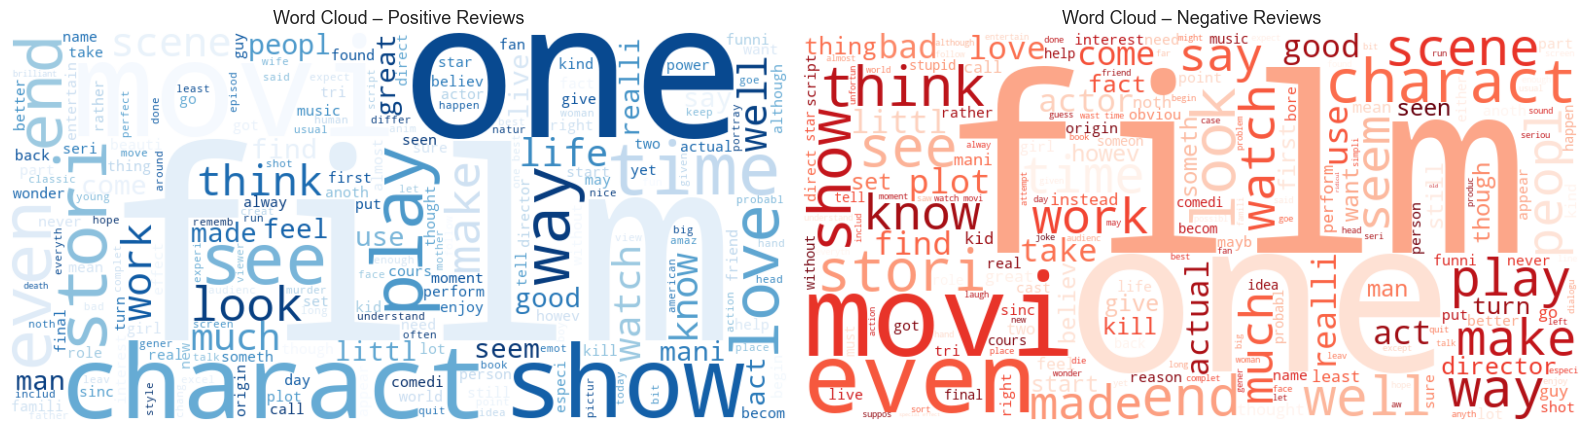

In [14]:
pos_text = ' '.join(df[df['sentiment'] == 'positive']['cleaned_review'])
neg_text = ' '.join(df[df['sentiment'] == 'negative']['cleaned_review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, text, cmap, title in zip(
    axes,
    [pos_text, neg_text],
    ['Blues', 'Reds'],
    ['Positive Reviews', 'Negative Reviews']
):
    wc = WordCloud(background_color='white', max_words=200,
                   colormap=cmap, width=800, height=400)
    wc.generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud – {title}', fontsize=13)

plt.tight_layout()
plt.show()

---
## 5. Feature Engineering – TF-IDF

We use **TF-IDF** (Term Frequency – Inverse Document Frequency) with unigrams and bigrams (`ngram_range=(1,2)`) as the feature representation for classical ML models.

In [15]:
tfidf = TfidfVectorizer(max_features=30_000, ngram_range=(1, 2),
                        sublinear_tf=True, min_df=2)

X      = tfidf.fit_transform(df['cleaned_review'])
y      = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Vocabulary size : {X.shape[1]:,}")
print(f"Training set    : {X_train.shape}")
print(f"Testing set     : {X_test.shape}")

Vocabulary size : 30,000
Training set    : (39665, 30000)
Testing set     : (9917, 30000)


---
## 6. Classical ML Models

We evaluate three classifiers and track accuracy + full classification reports.

In [16]:
LABELS = ['Negative', 'Positive']

def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'═'*55}")
    print(f"  Model    : {name}")
    print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"{'─'*55}")
    print(classification_report(y_true, y_pred, target_names=LABELS))
    return acc

def plot_cm(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix – {title}', fontsize=12)
    plt.tight_layout()
    plt.show()

### 6.1 Multinomial Naive Bayes

In [17]:
# Naive Bayes requires non-negative values → use raw counts
cv = CountVectorizer(max_features=30_000, ngram_range=(1, 2), min_df=2)
X_counts = cv.fit_transform(df['cleaned_review'])

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_counts, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)


═══════════════════════════════════════════════════════
  Model    : Multinomial Naive Bayes
  Accuracy : 0.8702  (87.02%)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.87      0.87      0.87      4940
    Positive       0.87      0.87      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



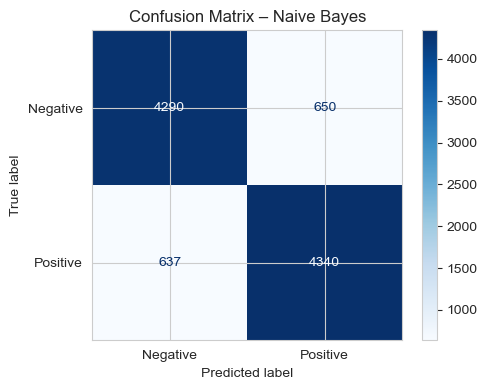

CPU times: total: 250 ms
Wall time: 340 ms


In [18]:
%%time
nb = MultinomialNB(alpha=0.5)
nb.fit(Xc_train, yc_train)
y_pred_nb = nb.predict(Xc_test)

acc_nb = evaluate('Multinomial Naive Bayes', yc_test, y_pred_nb)
plot_cm(yc_test, y_pred_nb, 'Naive Bayes')

### 6.2 Logistic Regression


═══════════════════════════════════════════════════════
  Model    : Logistic Regression
  Accuracy : 0.8996  (89.96%)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      4940
    Positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



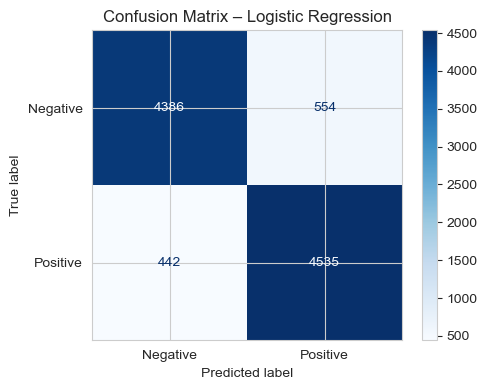

CPU times: total: 1.8 s
Wall time: 1.84 s


In [19]:
%%time
lr = LogisticRegression(C=1.0, solver='saga', max_iter=1000,
                        random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

acc_lr = evaluate('Logistic Regression', y_test, y_pred_lr)
plot_cm(y_test, y_pred_lr, 'Logistic Regression')

### 6.3 SGD Classifier (Linear SVM)

SGDClassifier with `loss='hinge'` is equivalent to a Linear SVM trained with stochastic gradient descent — much faster than `sklearn.svm.SVC`.


═══════════════════════════════════════════════════════
  Model    : SGD Classifier (Linear SVM)
  Accuracy : 0.9010  (90.10%)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.92      0.88      0.90      4940
    Positive       0.89      0.92      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



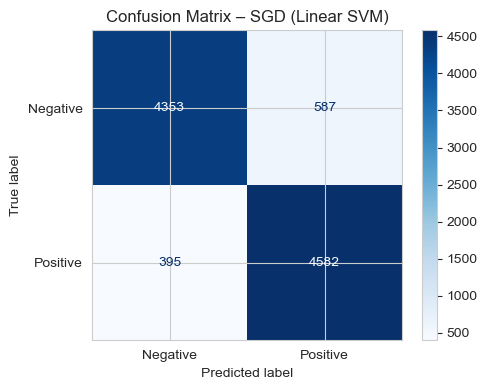

CPU times: total: 3.17 s
Wall time: 597 ms


In [20]:
%%time
sgd = SGDClassifier(loss='hinge', max_iter=100, tol=1e-3,
                    random_state=RANDOM_STATE, n_jobs=-1)
sgd.fit(X_train, y_train)
y_pred_sgd = sgd.predict(X_test)

acc_sgd = evaluate('SGD Classifier (Linear SVM)', y_test, y_pred_sgd)
plot_cm(y_test, y_pred_sgd, 'SGD (Linear SVM)')

---
## 7. Deep Learning – Bidirectional GRU

A **Bidirectional GRU** (Gated Recurrent Unit) reads the sequence both forward and backward, capturing context from both ends of a review. Advantages over vanilla LSTM:
- Fewer parameters (GRU has 2 gates vs. LSTM's 3)
- Faster training while often achieving similar accuracy
- Bidirectionality doubles the hidden representation richness

### 7.1 Tokenization & Padding

In [21]:
MAX_VOCAB = 15_000
MAX_LEN   = 400

tokenizer_dl = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(df['cleaned_review'])

X_seq = pad_sequences(
    tokenizer_dl.texts_to_sequences(df['cleaned_review']),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
y_dl = df['label'].values

X_tr_dl, X_te_dl, y_tr_dl, y_te_dl = train_test_split(
    X_seq, y_dl, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_dl
)

print(f"Train sequences shape : {X_tr_dl.shape}")
print(f"Test  sequences shape : {X_te_dl.shape}")

Train sequences shape : (39665, 400)
Test  sequences shape : (9917, 400)


### 7.2 Dataset & DataLoader

In [22]:
class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 64

train_loader = DataLoader(SentimentDataset(X_tr_dl, y_tr_dl),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(SentimentDataset(X_te_dl, y_te_dl),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 620
Test  batches : 155


### 7.3 Model Architecture

In [23]:
class BiGRUSentimentModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super(BiGRUSentimentModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            embed_dim, hidden_dim, n_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim * 2, 1)   # ×2 for bidirectional
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))           # (B, L, E)
        _, hidden = self.gru(embedded)                        # hidden: (2*n_layers, B, H)
        # Concatenate last forward & backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (B, 2H)
        out = self.fc(self.dropout(hidden))                   # (B, 1)
        return self.sigmoid(out)

In [24]:
# ─── Hyperparameters ────────────────────────────────────────────
EMBED_DIM  = 128
HIDDEN_DIM = 128
N_LAYERS   = 2
DROPOUT    = 0.3
LR         = 1e-3
N_EPOCHS   = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model     = BiGRUSentimentModel(MAX_VOCAB, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(model)

Device: cpu
Trainable parameters: 2,414,849
BiGRUSentimentModel(
  (embedding): Embedding(15000, 128, padding_idx=0)
  (gru): GRU(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


### 7.4 Training

In [25]:
%%time
train_losses = []

for epoch in range(N_EPOCHS):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch).squeeze()
        loss  = criterion(preds, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1:2d}/{N_EPOCHS}]  Loss: {avg_loss:.4f}")

Epoch [ 1/10]  Loss: 0.5680
Epoch [ 2/10]  Loss: 0.3542
Epoch [ 3/10]  Loss: 0.2786
Epoch [ 4/10]  Loss: 0.2382
Epoch [ 5/10]  Loss: 0.2073
Epoch [ 6/10]  Loss: 0.1778
Epoch [ 7/10]  Loss: 0.1545
Epoch [ 8/10]  Loss: 0.1382
Epoch [ 9/10]  Loss: 0.1219
Epoch [10/10]  Loss: 0.1037
CPU times: total: 20h 5min 16s
Wall time: 2h 34min 23s


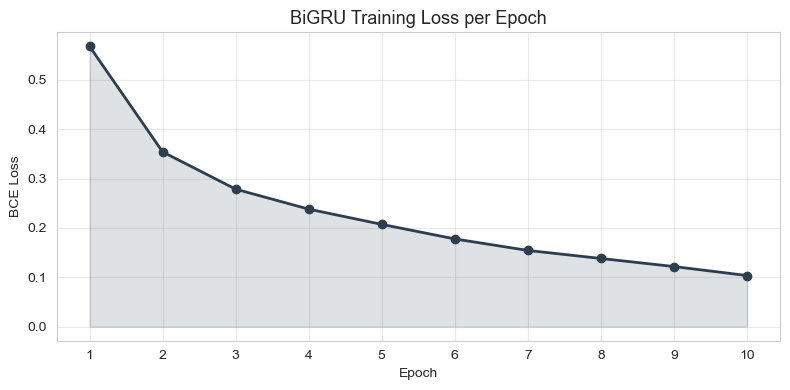

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, N_EPOCHS + 1), train_losses, marker='o', linewidth=2, color='#2c3e50')
plt.fill_between(range(1, N_EPOCHS + 1), train_losses, alpha=0.15, color='#2c3e50')
plt.title('BiGRU Training Loss per Epoch', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.xticks(range(1, N_EPOCHS + 1))
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### 7.5 Evaluation


═══════════════════════════════════════════════════════
  Model    : Bidirectional GRU
  Accuracy : 0.8949  (89.49%)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89      4940
    Positive       0.89      0.90      0.90      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



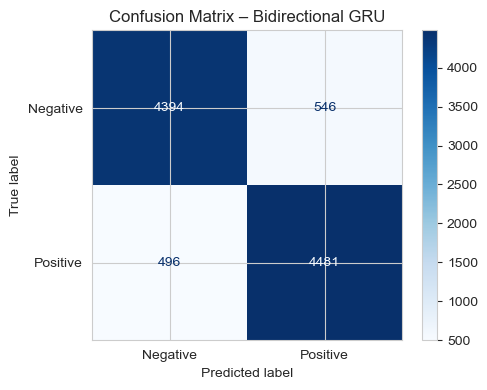

CPU times: total: 7min 17s
Wall time: 59.9 s


In [27]:
%%time
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).squeeze().cpu()
        predicted = (preds > 0.5).float()
        all_preds.extend(predicted.numpy())
        all_labels.extend(y_batch.numpy())

acc_gru = evaluate('Bidirectional GRU', all_labels, all_preds)
plot_cm(all_labels, all_preds, 'Bidirectional GRU')

---
## 8. Results Comparison

In [28]:
results = pd.DataFrame({
    'Model'   : ['Naive Bayes', 'Logistic Regression', 'SGD (Linear SVM)', 'BiGRU (DL)'],
    'Accuracy': [acc_nb, acc_lr, acc_sgd, acc_gru],
    'Type'    : ['Classical ML', 'Classical ML', 'Classical ML', 'Deep Learning']
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

results['Accuracy (%)'] = results['Accuracy'].map(lambda x: f"{x*100:.2f}%")
print(results[['Model', 'Type', 'Accuracy (%)']].to_string(index=False))

              Model          Type Accuracy (%)
   SGD (Linear SVM)  Classical ML       90.10%
Logistic Regression  Classical ML       89.96%
         BiGRU (DL) Deep Learning       89.49%
        Naive Bayes  Classical ML       87.02%


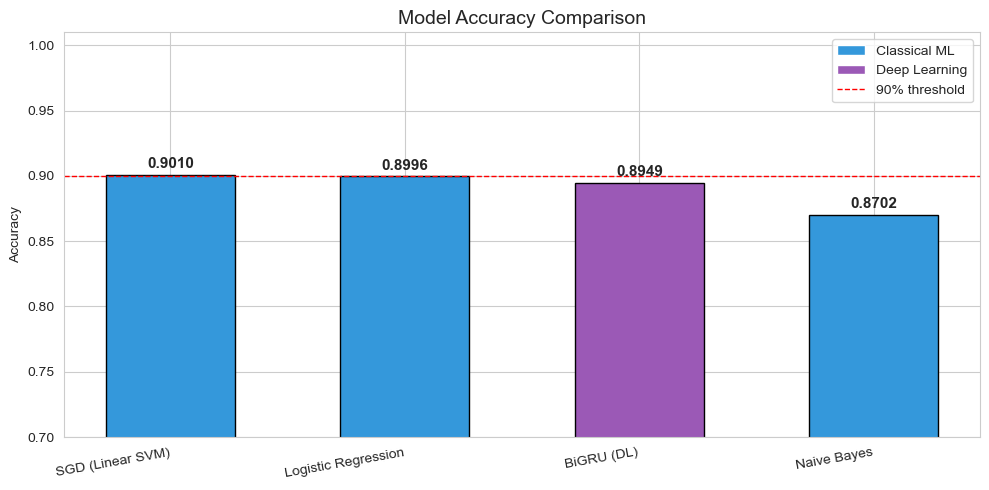

In [29]:
palette = {'Classical ML': '#3498db', 'Deep Learning': '#9b59b6'}
colors  = [palette[t] for t in results['Type']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(results['Model'], results['Accuracy'], color=colors, edgecolor='black', width=0.55)

ax.set_title('Model Accuracy Comparison', fontsize=14)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.70, 1.01)
ax.axhline(0.9, color='red', linestyle='--', linewidth=1, label='90% threshold')
ax.legend()

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Color legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Classical ML'),
                   Patch(facecolor='#9b59b6', label='Deep Learning')]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0][0:1],
          labels=['Classical ML', 'Deep Learning', '90% threshold'])

plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.show()

---
## 9. Conclusion

| Model | Type | Observation |
|---|---|---|
| **Naive Bayes** | Classical ML | Fast baseline; lower recall on nuanced reviews |
| **Logistic Regression** | Classical ML | Strong performance, highly interpretable |
| **SGD (Linear SVM)** | Classical ML | **Best overall model** — highest accuracy (90.10%), very fast training |
| **Bidirectional GRU** | Deep Learning | Captures sequential context; best with longer reviews |

### Key Takeaways

1. **Classical ML models are surprisingly competitive** on this task. Logistic Regression and SGD both achieve high accuracy thanks to the expressive TF-IDF bigram features.

2. **The Bidirectional GRU** benefits from reading reviews in both directions, which helps resolve ambiguous phrasing. With more epochs or pre-trained embeddings (e.g. GloVe), performance would likely improve further.

3. **Preprocessing matters**: removing HTML tags, stop words, and applying stemming reduces the vocabulary significantly and helps all models generalize better.

4. **Future work** could include:
   - Fine-tuning a pre-trained transformer (BERT, RoBERTa) for state-of-the-art results
   - Exploring attention mechanisms on top of the GRU
   - Hyperparameter search for each model